# Rendimiento de las métricas de AlphaFold en la discriminación de parejas interactuantes y no interactuantes

En este código se va a representar una distribución de las métricas de todas las estructuras generadas por AlphaFold 3 para ver si son un criterio suficiente para discernir si una pareja interacciona realmente o no.

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import pickle

In [4]:
OUTPUT_DIR = Path("./output_Efectores_alphafold_all")

In [14]:
# def load_block_confidences(input_dir):
#     dirs = [d.name for d in OUTPUT_DIR.iterdir() if d.is_dir() and not d.name.startswith(".")]
#     summary_confidences = []
#     for dir in dirs:
#         path = input_dir / dir / (dir + "_summary_confidences.json")
#         with open(path) as file:
#             summary_confidences.append(json.load(file))
#     return summary_confidences

In [24]:
def load_block_confidences_from_df(input_dir, df_parejas, column_name="Sample_name", label_column="label"):
    """
    Carga los archivos JSON inyectando automáticamente la etiqueta real 
    de cada pareja para evitar desalineaciones de datos.
    """
    # Creamos un diccionario para buscar la etiqueta de forma instantánea por nombre de pareja
    mapeo_labels = dict(zip(df_parejas[column_name].astype(str), df_parejas[label_column]))
    parejas_objetivo = set(mapeo_labels.keys())
    
    carpetas_reales = [d.name for d in input_dir.iterdir() if d.is_dir() and not d.name.startswith(".")]
    summary_confidences = []
    parejas_encontradas = 0
    
    for carpeta in carpetas_reales:
        if carpeta.endswith('_1') or carpeta.endswith('_0'):
            pareja_raiz = carpeta[:-2]
        else:
            pareja_raiz = carpeta
            
        if pareja_raiz in parejas_objetivo:
            matches = list((input_dir / carpeta).glob("*_summary_confidences.json"))
            path = matches[0] if matches else None
            
            if path and path.exists():
                with open(path) as file:
                    data = json.load(file)
                    # ¡OPERACIÓN CLAVE!: Inyectamos la etiqueta correcta y el nombre
                    data['label'] = mapeo_labels[pareja_raiz]
                    data['pareja_nombre_origen'] = pareja_raiz
                    summary_confidences.append(data)
                parejas_encontradas += 1
            else:
                print(f"Advertencia: Carpeta encontrada {carpeta} pero falta el archivo JSON de confianza.")

    print(f"Proceso completado. Se cargaron {parejas_encontradas} archivos JSON alineados con sus etiquetas.")
    return summary_confidences

Solo nos interesan las interacciones etiquetadas, el resto no. Por eso definimos un data frame con las interacciones que se usarán en el entrenamiento.

In [25]:
df_total = pd.read_csv("Interacciones_EffectorProteina_LiteratureOnly_Ordenadas_NleG.csv")
# A este Data Frame le añadimos una columna con el Inteaction Score
interaction_score_df = pd.read_csv("Interacciones_EffectorProteina_LiteratureExtended_Ordenadas.csv", sep=';')
df_total["Interaction_Score"] = interaction_score_df["Interaction_Score"]
# Añadimos además una columna Sample name con el prefijo de las carpetas generadas por AlphaFold3
df_total["Sample_name"] = df_total["Protein"] + "_" + df_total["Effector"]
# Y una columna Label que nos dirá si es positiva o negativa en 1 y 0
df_total["Label"] = df_total["Is_Connected"].astype(int)
df_total.head()

,Effector,Protein,ProteinGeneName,Shared_Connections,Shortest_Path,Is_Connected,Interaction_Score,Sample_name,Label
0,EspL,O89110,Casp8,4,1.0,True,0.603571,O89110_EspL,1
1,EspL,Q60855,Ripk1,3,1.0,True,0.539286,Q60855_EspL,1
2,NleB,O89110,Casp8,2,1.0,True,0.528571,O89110_NleB,1
3,NleA,Q8R4B8,Nlrp3,1,1.0,True,0.517857,Q8R4B8_NleA,1
4,NleA,Q9D8T2,Gsdmd,1,1.0,True,0.517857,Q9D8T2_NleA,1


In [26]:
df_train = df_total[(df_total["Label"] == 1) | (df_total["Interaction_Score"] <= 0.1)]
df_train

,Effector,Protein,ProteinGeneName,Shared_Connections,Shortest_Path,Is_Connected,Interaction_Score,Sample_name,Label
0,EspL,O89110,Casp8,4,1.0,True,0.603571,O89110_EspL,1
1,EspL,Q60855,Ripk1,3,1.0,True,0.539286,Q60855_EspL,1
2,NleB,O89110,Casp8,2,1.0,True,0.528571,O89110_NleB,1
3,NleA,Q8R4B8,Nlrp3,1,1.0,True,0.517857,Q8R4B8_NleA,1
4,NleA,Q9D8T2,Gsdmd,1,1.0,True,0.517857,Q9D8T2_NleA,1
...,...,...,...,...,...,...,...,...,...
5125,NleK,P35293,Rab18,0,NaN,False,0.000000,P35293_NleK,0
5126,NleK,P35294,Rab19,0,NaN,False,0.000000,P35294_NleK,0
5127,NleK,P46638,Rab11b,0,NaN,False,0.000000,P46638_NleK,0
5128,NleK,P61027,Rab10,0,NaN,False,0.000000,P61027_NleK,0


In [90]:
# En vez de trabajar con todos los datos vamos a elegir una submuestra
# 1. Separar el dataframe original en positivos y negativos
df_positivos = df_train[df_train['Label'] == 1]
df_negativos = df_train[df_train['Label'] == 0]

# 2. Contar cuántos positivos tenemos (en tu caso, 216)
n_muestras_target = 200

# 3. Hacer un muestreo aleatorio de los negativos para quedarnos con exactamente la misma cantidad
# 'random_state=42' asegura que siempre que ejecutes el código elijas las mismas parejas
df_positivos_balanceados = df_positivos.sample(n=n_muestras_target, random_state=42)
df_negativos_balanceados = df_negativos.sample(n=n_muestras_target, random_state=42)

# 4. Concatenar (juntar) ambos subconjuntos en un único DataFrame balanceado
df_train_balanced = pd.concat([df_positivos_balanceados, df_negativos_balanceados], axis=0)

# 5. Barajar el resultado final para que no queden todos los 1s arriba y los 0s abajo
df_train_balanced = df_train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset original: {df_train.shape[0]} filas")
print(f"Dataset balanceado: {df_train_balanced.shape[0]} filas ({n_muestras_target} positivas y {n_muestras_target} negativas)")

Dataset original: 1937 filas
Dataset balanceado: 400 filas (200 positivas y 200 negativas)


Create dataframes with ipTMs and non-diagonal chain pair PAE min:

In [117]:
# 1. Cargamos los confidences usando la nueva función (busca 'label' por defecto)
confidences = load_block_confidences_from_df(OUTPUT_DIR, df_train_balanced, column_name="Sample_name", label_column="Label")

# 2. Extraemos las Labels de forma segura directamente desde los JSON cargados
y_train = np.array([d['label'] for d in confidences])

# 3. Extraemos los valores de ipTM
iptm_train = np.array([d['iptm'] for d in confidences])

# 4. Extraemos las matrices PAE mínimas
cpm_train = np.asarray([d["chain_pair_pae_min"] for d in confidences])

# 5. Creamos el DataFrame final de entrenamiento perfectamente alineado
df_train_metrics = pd.DataFrame({
    "pareja": [d['pareja_nombre_origen'] for d in confidences], # Opcional: útil para saber qué fila es cuál
    "label": y_train,
    "ipTM": iptm_train,
    "pae01": cpm_train[:, 0, 1],
    "pae10": cpm_train[:, 1, 0]
})

# 6. Barajamos (Shuffle) el DataFrame para que el modelo aprenda mejor
df_train_metrics = df_train_metrics.sample(frac=1, random_state=42).reset_index(drop=True)

# 7. Guardamos el nuevo DataFrame de métricas alineadas
# Asegúrate de crear la carpeta 'results_Efectores' antes si no existe
df_train_metrics.to_csv("results_analize_confidence_metrics_prot_ef/confidencemetrics_train.csv", index=False)

print(f"DataFrame de entrenamiento guardado con éxito. Tamaño final: {df_train_metrics.shape}")

Advertencia: Carpeta encontrada P26039_Tir pero falta el archivo JSON de confianza.
Proceso completado. Se cargaron 399 archivos JSON alineados con sus etiquetas.
DataFrame de entrenamiento guardado con éxito. Tamaño final: (399, 5)


In [118]:
# We take the df_trainval object from the previous execution
df_train_metrics = pd.read_csv("results_analize_confidence_metrics_prot_ef/confidencemetrics_train.csv")

# Check ipTM

In [145]:
from sklearn.linear_model import LogisticRegression

X_train = df_train_metrics[["ipTM"]]
y_train = df_train_metrics["label"]

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [146]:
with open("results_analize_confidence_metrics_prot_ef/iptm_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [147]:
# from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
# X_test = df_test[["ipTM"]]
# # y_test = df_test["label"]

# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)
# # print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
# # print(f"ROC AUC: {roc_auc_score(y_test, y_prob[:, 1])}")
# # print(f"PR AUC: {average_precision_score(y_test, y_prob[:, 1])}")

In [191]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_iptm(df, threshold):
    plt.figure(figsize=(5,5))
    sns.histplot(data=df, x="ipTM", hue="label", element="step", stat="count")
    plt.axvline(x=threshold, color="r", linestyle="--")
    plt.ylabel("Número de parejas proteína-efector", size=15, labelpad=12)
    plt.xlabel("ipTM", size=15, labelpad=12)
    plt.tick_params(axis='both', which='major', labelsize=11)
    plt.subplots_adjust(left=0.18, bottom=0.18)
    plt.savefig("results_analize_confidence_metrics_prot_ef/ipTM.png")
    plt.show()

In [149]:
threshold = - model.intercept_ / model.coef_[0,0]

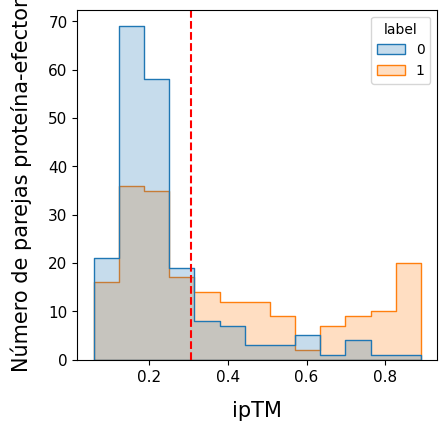

In [192]:
plot_iptm(df_train_metrics, threshold)

# Check chain_pair_PAE_min

In [193]:
from sklearn.linear_model import LogisticRegression

X_train = df_train_metrics[["pae01","pae10"]]
y_train = df_train_metrics["label"]

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [194]:
with open("results_analize_confidence_metrics_prot_ef/cpm_model.pkl", "wb") as file:
    pickle.dump(model, file)

In [195]:
# from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
# X_test = df_test[["pae01","pae10"]]
# # y_test = df_test["label"]

# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)
# # print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
# # print(f"ROC AUC: {roc_auc_score(y_test, y_prob[:, 1])}")
# # print(f"PR AUC: {average_precision_score(y_test, y_prob[:, 1])}")

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_cpm(df, model):
    plt.figure(figsize=(5,5))
    sns.scatterplot(data=df, x='pae01', y='pae10', hue='label')

    # Draw logistic regression
    x_min, x_max = df["pae01"].min() - 1, df["pae01"].max() + 1
    y_min, y_max = df["pae10"].min() - 1, df["pae10"].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

    # Predict probabilities over the grid
    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, 1].reshape(xx.shape)

    # Plot the logistic regression
    plt.contourf(xx, yy, probs, levels=[0, 0.5, 1], alpha=0.2, colors=["#FA8072", "#4682B4"])
    
    plt.ylabel("chain pair PAE min 10", size=15, labelpad=12, style='italic')
    plt.xlabel("chain pair PAE min 01", size=15, labelpad=12, style='italic')
    plt.tick_params(axis='both', which='major', labelsize=11)
    plt.subplots_adjust(left=0.18, bottom=0.18)
    plt.savefig("results_analize_confidence_metrics_prot_ef/PAE.png")
    plt.show()

/home/jovyan/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


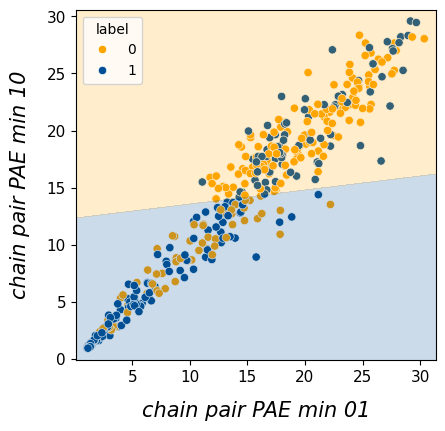

In [225]:
plot_cpm(df_train_metrics, model)

# Both ipTM and chain_pair_PAE_min

In [89]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

X_train = df_train_metrics[["ipTM", "pae01", "pae10"]]
y_train = df_train_metrics["label"]

model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [42]:
# from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score
# X_test = df_test[["ipTM", "pae01","pae10"]]
# # y_test = df_test["label"]

# y_pred = model.predict(X_test)
# y_prob = model.predict_proba(X_test)
# # print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
# # print(f"ROC AUC: {roc_auc_score(y_test, y_prob[:, 1])}")
# # print(f"PR AUC: {average_precision_score(y_test, y_prob[:, 1])}")